# Phase 5: Statistical Analysis
## Supply Chain & Manufacturing Analytics Platform

**Analyses covered:**
1. Hypothesis Testing — Do supplier delays affect production downtime?
2. Regression Modeling — Can we predict shipment cost?
3. Correlation Analysis — Does lead time relate to stock-out risk?
4. Outlier Detection — Any abnormal costs or extreme downtime?

---
## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import pearsonr, mannwhitneyu, pointbiserialr
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

print('Libraries imported.')

Libraries imported.


---
## Loading Data

loading the **cleaned fact tables** exported from SQL Server (Phase 2), plus `calendar.csv` and `suppliers.csv` to decode the integer surrogate keys stored in the fact tables.

In [3]:
# Fact tables — exported from SQL Server after Phase 2 ETL
purchase   = pd.read_csv("CleanData/fact_purchase_clean.csv")
logistics  = pd.read_csv("CleanData/fact_logistics_clean.csv")
production = pd.read_csv("CleanData/fact_production_clean.csv")
inventory  = pd.read_csv("CleanData/fact_inventory_clean.csv")

# Dimension lookups
calendar  = pd.read_csv("ExcelFiles/calendar.csv")   # decodes date keys → actual dates
suppliers = pd.read_csv("ExcelFiles/suppliers.csv")  # decodes supplier keys → names

print('Rows loaded:')
for name, df in [('purchase',purchase),('logistics',logistics),
                 ('production',production),('inventory',inventory)]:
    print(f'  {name:12}: {len(df):,}')

Rows loaded:
  purchase    : 795
  logistics   : 963
  production  : 1,200
  inventory   : 120


---
## Data Quality Check

In [7]:
# Missing values
print("--- Missing Values ---")
for name, df in [('purchase',purchase),('logistics',logistics),
                 ('production',production),('inventory',inventory)]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls):
        print(f'{name}:', nulls.to_dict())
    else:
        print(f'{name}: no missing values')

print()

# Duplicates
print('--- Duplicate Rows ---')
for name, df in [('purchase',purchase),('logistics',logistics),
                 ('production',production),('inventory',inventory)]:
    print(f'{name}: {df.duplicated().sum()}')

--- Missing Values ---
purchase: no missing values
logistics: no missing values
production: {'downtime_reason': 222}
inventory: no missing values

--- Duplicate Rows ---
purchase: 0
logistics: 0
production: 0
inventory: 0


In [9]:
# production rows have no downtime_reason recorded , filling with 'Unknown'
production['downtime_reason'] = production['downtime_reason'].fillna('Unknown')
print('downtime_reason values:')
print(production['downtime_reason'].value_counts())

downtime_reason values:
downtime_reason
Maintenance          275
Material Shortage    249
Labor Issue          232
Machine Failure      222
Unknown              222
Name: count, dtype: int64


---
## Preparing Data

The fact tables store dates as integer surrogate keys(e.g. `order_date_key = 2`). So, we decode them by joining `calendar.csv` where row position = date_key (1-based). Then we compute the real delivery delay and lead time in calendar days.

In [12]:
# Build Dim_Date: row position = date_key
calendar['date_key']  = range(1, len(calendar)+1)
calendar['full_date'] = pd.to_datetime(calendar['date'], dayfirst=True, errors='coerce')
dim_date = calendar[['date_key','full_date']]

# Build Dim_Supplier: row position = supplier_key
suppliers['supplier_key'] = range(1, len(suppliers)+1)

# Transport mode key → name (confirmed from data)
transport_map = {1:'Air', 2:'Rail', 3:'Road', 4:'Sea'}

In [14]:
# Decode purchase: join dim_date 3 times to get real order/promised/actual dates
purchase_enriched = (
    purchase
    .merge(dim_date.rename(columns={'date_key':'order_date_key',    'full_date':'order_date'}),    on='order_date_key',    how='left')
    .merge(dim_date.rename(columns={'date_key':'promised_date_key', 'full_date':'promised_date'}), on='promised_date_key', how='left')
    .merge(dim_date.rename(columns={'date_key':'actual_date_key',   'full_date':'actual_date'}),   on='actual_date_key',   how='left')
    .merge(suppliers[['supplier_key','supplier_name']], on='supplier_key', how='left')
)

# delivery_delay_days: positive = late, 0 or negative = on time / early
purchase_enriched['delivery_delay_days'] = (purchase_enriched['actual_date'] - purchase_enriched['promised_date']).dt.days
# lead_time_days: total days from order placement to delivery
purchase_enriched['lead_time_days']      = (purchase_enriched['actual_date'] - purchase_enriched['order_date']).dt.days

print('Sample decoded purchase rows:')
display(purchase_enriched[['supplier_name','order_date','promised_date','actual_date',
                            'delivery_delay_days','lead_time_days']].head(5))

Sample decoded purchase rows:


,supplier_name,order_date,promised_date,actual_date,delivery_delay_days,lead_time_days
0,Supplier_9,2019-01-02,2019-01-16,2019-01-24,8,22
1,Supplier_4,2019-01-04,2019-01-14,2019-01-17,3,13
2,Supplier_5,2019-01-05,2019-01-14,2019-01-15,1,10
3,Supplier_3,2019-01-06,2019-01-10,2019-01-15,5,9
4,Supplier_9,2019-01-10,2019-01-22,2019-01-26,4,16


In [16]:
# Enrich logistics: decode transport mode + join quantity from purchase
logistics_enriched = logistics.copy()
logistics_enriched['transport_mode'] = logistics_enriched['transport_mode_key'].map(transport_map)
logistics_enriched = logistics_enriched.merge(
    purchase_enriched[['purchase_fact_key','product_key','quantity','delivery_delay_days']],
    on='purchase_fact_key', how='inner'
)

# Inventory: flag rows where stock is below reorder level
inventory['stockout_flag'] = (inventory['current_stock'] < inventory['reorder_level']).astype(int)

print(f'logistics_enriched: {logistics_enriched.shape}')
print(f'Stockout rate: {inventory["stockout_flag"].mean()*100:.1f}%')

logistics_enriched: (963, 9)
Stockout rate: 11.7%


---
## Analysis 1 — Hypothesis Testing
### Effect of Supplier Delays on Production Downtime

**H₀:** Supplier delivery delays have NO significant effect on production downtime  
**H₁:** Supplier delivery delays significantly increase production downtime  
**α = 0.05** — reject H₀ if p-value < 0.05

We aggregate at the product level (one value per product), then run two tests:
- **Pearson Correlation** — tests linear relationship
- **Mann-Whitney U** — non-parametric, compares high-delay vs low-delay groups

In [19]:
# Aggregate: one avg delay and avg downtime per product
prod_delay    = purchase_enriched.groupby('product_key')['delivery_delay_days'].mean().reset_index().rename(columns={'delivery_delay_days':'avg_delay'})
prod_downtime = production.groupby('product_key')['downtime_hours'].mean().reset_index().rename(columns={'downtime_hours':'avg_downtime'})
hyp_df = prod_delay.merge(prod_downtime, on='product_key', how='inner')

print(f'Products in analysis: {len(hyp_df)}')
display(hyp_df[['avg_delay','avg_downtime']].describe().round(2))

Products in analysis: 30


,avg_delay,avg_downtime
count,30.00,30.00
mean,3.36,1.98
std,0.70,0.38
min,2.07,1.16
25%,2.91,1.79
50%,3.27,1.96
75%,3.72,2.27
max,4.85,2.68


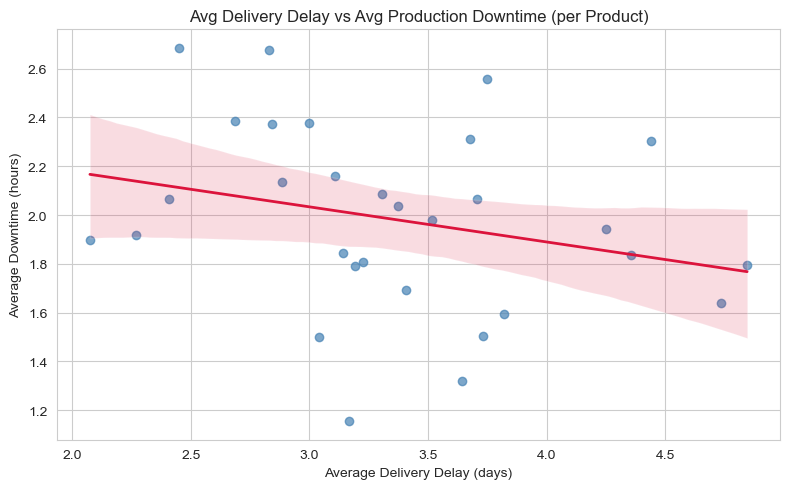

In [21]:
# Scatter plot
plt.figure(figsize=(8,5))
sns.regplot(data=hyp_df, x='avg_delay', y='avg_downtime',
            scatter_kws={'alpha':0.7,'color':'steelblue'},
            line_kws={'color':'crimson','linewidth':2})
plt.title('Avg Delivery Delay vs Avg Production Downtime (per Product)')
plt.xlabel('Average Delivery Delay (days)')
plt.ylabel('Average Downtime (hours)')
plt.tight_layout()
plt.show()

In [23]:
# Test 1: Pearson Correlation
corr, p_val = pearsonr(hyp_df['avg_delay'], hyp_df['avg_downtime'])
print('=== Pearson Correlation ===')
print(f'r = {corr:.4f}')
print(f'p = {p_val:.4f}')
print()
if p_val < 0.05:
    print('RESULT: p < 0.05 → REJECT H₀ — delays significantly affect downtime.')
else:
    print('RESULT: p ≥ 0.05 → FAIL TO REJECT H₀ — no significant linear relationship.')

=== Pearson Correlation ===
r = -0.2654
p = 0.1564

RESULT: p ≥ 0.05 → FAIL TO REJECT H₀ — no significant linear relationship.


In [25]:
# Test 2: Mann-Whitney U — split products at median delay
median_delay   = hyp_df['avg_delay'].median()
high_delay_grp = hyp_df[hyp_df['avg_delay'] >  median_delay]['avg_downtime']
low_delay_grp  = hyp_df[hyp_df['avg_delay'] <= median_delay]['avg_downtime']

u_stat, mw_p = mannwhitneyu(high_delay_grp, low_delay_grp, alternative='greater')

print('=== Mann-Whitney U Test ===')
print(f'Median delay threshold : {median_delay:.2f} days')
print(f'High-delay avg downtime: {high_delay_grp.mean():.2f} hrs')
print(f'Low-delay avg downtime : {low_delay_grp.mean():.2f} hrs')
print(f'U = {u_stat:.2f},  p = {mw_p:.4f}')
print()
if mw_p < 0.05:
    print('RESULT: p < 0.05 → High-delay products have significantly more downtime.')
else:
    print('RESULT: p ≥ 0.05 → No significant downtime difference between the two groups.')

=== Mann-Whitney U Test ===
Median delay threshold : 3.27 days
High-delay avg downtime: 1.91 hrs
Low-delay avg downtime : 2.05 hrs
U = 86.00,  p = 0.8686

RESULT: p ≥ 0.05 → No significant downtime difference between the two groups.


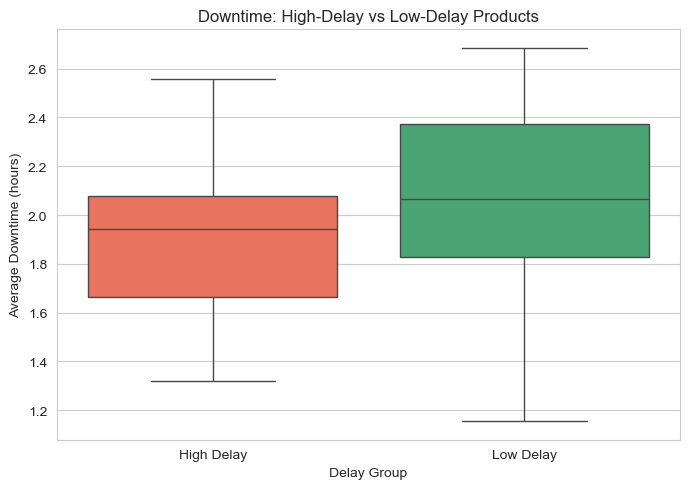

In [27]:
# Box plot comparison
hyp_df['delay_group'] = hyp_df['avg_delay'].apply(
    lambda x: 'High Delay' if x > median_delay else 'Low Delay'
)

plt.figure(figsize=(7,5))
sns.boxplot(data=hyp_df, x='delay_group', y='avg_downtime',
            palette={'High Delay':'tomato','Low Delay':'mediumseagreen'})
plt.title('Downtime: High-Delay vs Low-Delay Products')
plt.xlabel('Delay Group')
plt.ylabel('Average Downtime (hours)')
plt.tight_layout()
plt.show()

### Interpretation
- **Pearson r = -0.2654, p = 0.1564** — no statistically significant linear relationship between delivery delay and production downtime.
- **Mann-Whitney p = 0.8686** — high-delay and low-delay products show no significant difference in downtime.
- **Conclusion:** We fail to reject H₀. Supplier delays do not directly cause production downtime in this dataset. Downtime is likely driven by internal factors — machine failures, maintenance, or material shortages.

---
## Analysis 2 — Regression Modeling
### Predicting Logistics Cost from Transport Mode, Delay, and Order Volume

**Target (y):** `shipment_cost`  
**Features (X):** transport mode (one-hot encoded), transit delay days, order quantity

In [31]:
# Build feature matrix
# One-hot encode transport_mode — treating it as a number would be wrong
# (Air=1 doesn't mean it costs half of Rail=2)
reg_df  = logistics_enriched[['transport_mode','transit_delay_days','quantity','shipment_cost']].dropna()
dummies = pd.get_dummies(reg_df['transport_mode'], prefix='mode', drop_first=True)  # Air is baseline
X = pd.concat([reg_df[['transit_delay_days','quantity']], dummies], axis=1)
y = reg_df['shipment_cost']

print(f'Features: {list(X.columns)}')
print(f'Rows    : {len(X)}')

Features: ['transit_delay_days', 'quantity', 'mode_Rail', 'mode_Road', 'mode_Sea']
Rows    : 963


In [33]:
# Train / test split (80/20) and fit Linear Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

r2   = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))

print('=== Linear Regression Results ===')
print(f'R²   : {r2:.4f}   (1 = perfect, 0 = no better than the mean)')
print(f'RMSE : ${rmse:.2f}  (average prediction error in dollars)')
print()
print('Feature Coefficients ($ change per unit increase):')
coeff_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_.round(2)})
display(coeff_df)

=== Linear Regression Results ===
R²   : 0.0140   (1 = perfect, 0 = no better than the mean)
RMSE : $1461.14  (average prediction error in dollars)

Feature Coefficients ($ change per unit increase):


,Feature,Coefficient
0,transit_delay_days,6.90
1,quantity,0.16
2,mode_Rail,-249.50
3,mode_Road,-220.89
4,mode_Sea,-64.05


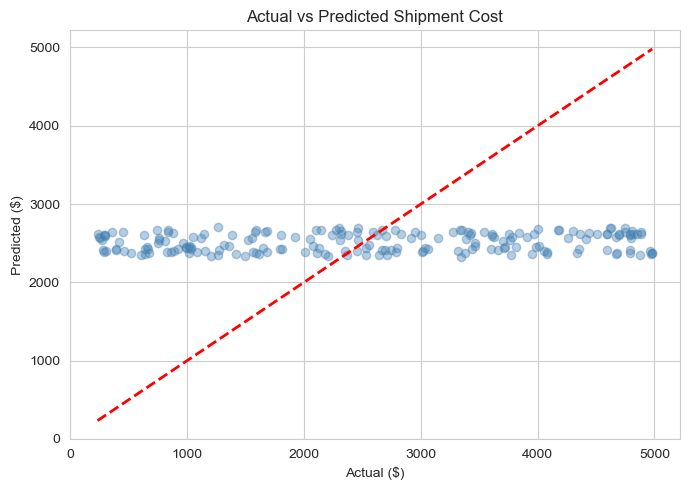

In [35]:
# Actual vs Predicted
plt.figure(figsize=(7,5))
plt.scatter(y_test, pred, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs Predicted Shipment Cost')
plt.xlabel('Actual ($)')
plt.ylabel('Predicted ($)')
plt.tight_layout()
plt.show()

=== Average Shipment Cost by Transport Mode ===
transport_mode
Air     2718.32
Sea     2553.96
Road    2413.89
Rail    2390.04


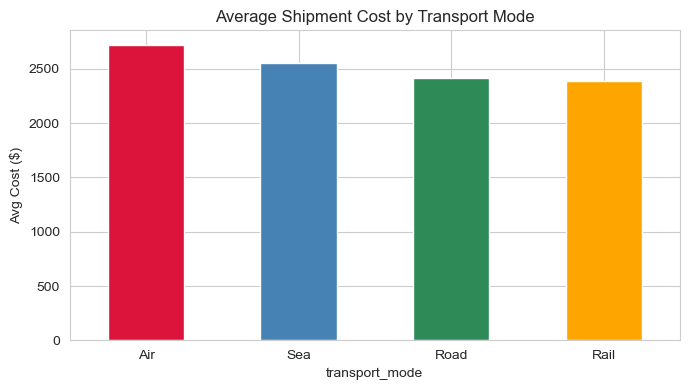

In [37]:
# Average cost by transport mode — direct business insight
cost_by_mode = (
    logistics_enriched.groupby('transport_mode')['shipment_cost']
    .mean().sort_values(ascending=False).round(2)
)
print('=== Average Shipment Cost by Transport Mode ===')
print(cost_by_mode.to_string())

plt.figure(figsize=(7,4))
cost_by_mode.plot(kind='bar', color=['crimson','steelblue','seagreen','orange'], edgecolor='white')
plt.title('Average Shipment Cost by Transport Mode')
plt.ylabel('Avg Cost ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation
- **R² = 0.014** — transport mode, transit delay, and order quantity together explain only ~1.4% of shipment cost variance. The model has very low predictive power.
- **RMSE = $1,461** — on average the model's prediction is off by $1,461.
- **Conclusion:** Shipment cost is driven by factors not in this dataset — likely distance, shipment weight, or carrier-specific pricing. The average cost breakdown shows **Air is the most expensive mode ($2,718)** and **Rail the cheapest ($2,390)**. Switching non-urgent orders from Air to Rail/Road is an actionable cost reduction opportunity.

---
## Analysis 3 — Correlation Analysis
### Lead Time vs Stock-Out Frequency

Do products with longer supplier lead times have higher stock-out risk?

We use **Point-Biserial Correlation** — the correct test when one variable is continuous (lead time) and the other is binary (stockout: 0 or 1).

In [41]:
# Average lead time per product
prod_lt = (
    purchase_enriched.groupby('product_key')['lead_time_days']
    .mean().reset_index().rename(columns={'lead_time_days':'avg_lead_time'})
)

# Stock-out risk per product: 1 if ANY warehouse is below reorder level
prod_so = (
    inventory.groupby('product_key')['stockout_flag']
    .max().reset_index().rename(columns={'stockout_flag':'stockout_risk'})
)

corr_df = prod_lt.merge(prod_so, on='product_key', how='inner')
corr_df['risk_label'] = corr_df['stockout_risk'].map({0:'Safe', 1:'At Risk'})

print(f'Products: {len(corr_df)}')
print(f'At risk : {corr_df["stockout_risk"].sum()}')
print(f'Safe    : {(corr_df["stockout_risk"]==0).sum()}')

Products: 30
At risk : 13
Safe    : 17


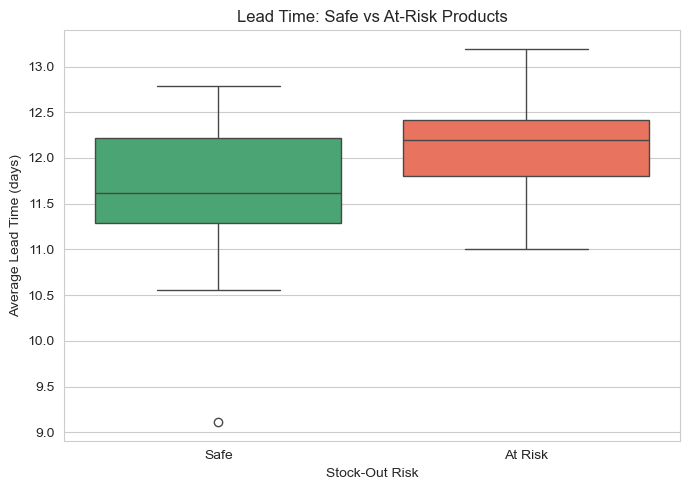

In [43]:
# Box plot: lead time for safe vs at-risk products
plt.figure(figsize=(7,5))
sns.boxplot(data=corr_df, x='risk_label', y='avg_lead_time',
            palette={'Safe':'mediumseagreen','At Risk':'tomato'})
plt.title('Lead Time: Safe vs At-Risk Products')
plt.xlabel('Stock-Out Risk')
plt.ylabel('Average Lead Time (days)')
plt.tight_layout()
plt.show()

In [45]:
# Point-Biserial Correlation
pb_corr, pb_pval = pointbiserialr(corr_df['stockout_risk'], corr_df['avg_lead_time'])

print('=== Point-Biserial Correlation: Lead Time vs Stock-Out Risk ===')
print(f'r = {pb_corr:.4f}')
print(f'p = {pb_pval:.4f}')
print()

if pb_pval < 0.05:
    print('RESULT: p < 0.05 → Significant relationship.')
    print('Longer lead times are associated with higher stock-out risk.' if pb_corr > 0 else 'Longer lead times are associated with lower stock-out risk.')
else:
    print('RESULT: p ≥ 0.05 → No statistically significant relationship.')
    print('Lead time alone does not predict stock-out risk.')

print()
print('Lead time summary by group:')
display(corr_df.groupby('risk_label')['avg_lead_time'].describe().round(2))

=== Point-Biserial Correlation: Lead Time vs Stock-Out Risk ===
r = 0.3501
p = 0.0579

RESULT: p ≥ 0.05 → No statistically significant relationship.
Lead time alone does not predict stock-out risk.

Lead time summary by group:


,count,mean,std,min,25%,50%,75%,max
risk_label,,,,,,,,
At Risk,13.0,12.10,0.64,11.00,11.81,12.20,12.42,13.19
Safe,17.0,11.53,0.87,9.11,11.29,11.62,12.21,12.79


### Interpretation
- **r = 0.3501, p = 0.0579** — marginally above the 0.05 threshold, so not statistically significant at the standard level.
- **Conclusion:** Lead time does not significantly predict stock-out risk on its own. The positive correlation (r = 0.35) suggests a weak directional trend — products with longer lead times tend to have slightly more stock-out risk — but the evidence is not strong enough to be conclusive. Other factors like demand variability and reorder policy are likely stronger drivers.

---
## 8. Analysis 4 — Outlier Detection
### Abnormal Logistics Costs and Extreme Downtime Events

**IQR Method:** values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are flagged as outliers.

In [49]:
def iqr_bounds(s):
    Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5*IQR, Q3 + 1.5*IQR

# Shipment cost outliers
cost_lo, cost_hi = iqr_bounds(logistics_enriched['shipment_cost'])
cost_outliers    = logistics_enriched[
    (logistics_enriched['shipment_cost'] < cost_lo) |
    (logistics_enriched['shipment_cost'] > cost_hi)
]

# Downtime outliers
dt_lo, dt_hi  = iqr_bounds(production['downtime_hours'])
dt_outliers   = production[
    (production['downtime_hours'] < dt_lo) |
    (production['downtime_hours'] > dt_hi)
]

print('=== Shipment Cost ===')
print(f'IQR fences : ${cost_lo:.0f}  to  ${cost_hi:.0f}')
print(f'Outliers   : {len(cost_outliers)} / {len(logistics_enriched)} ({len(cost_outliers)/len(logistics_enriched)*100:.1f}%)')
print()
print('=== Production Downtime ===')
print(f'IQR fences : {dt_lo:.2f}h  to  {dt_hi:.2f}h')
print(f'Outliers   : {len(dt_outliers)} / {len(production)} ({len(dt_outliers)/len(production)*100:.1f}%)')

=== Shipment Cost ===
IQR fences : $-2258  to  $7232
Outliers   : 0 / 963 (0.0%)

=== Production Downtime ===
IQR fences : -2.65h  to  5.83h
Outliers   : 63 / 1200 (5.2%)


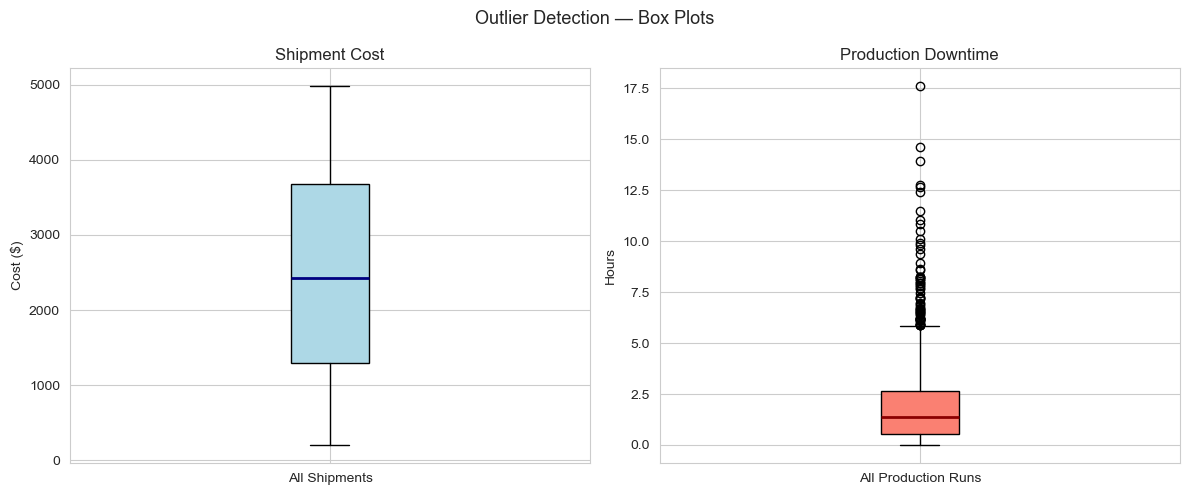

In [51]:
# Box plots side by side
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].boxplot(logistics_enriched['shipment_cost'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='navy', linewidth=2))
axes[0].set_title('Shipment Cost')
axes[0].set_ylabel('Cost ($)')
axes[0].set_xticklabels(['All Shipments'])

axes[1].boxplot(production['downtime_hours'], patch_artist=True,
                boxprops=dict(facecolor='salmon'),
                medianprops=dict(color='darkred', linewidth=2))
axes[1].set_title('Production Downtime')
axes[1].set_ylabel('Hours')
axes[1].set_xticklabels(['All Production Runs'])

plt.suptitle('Outlier Detection — Box Plots', fontsize=13)
plt.tight_layout()
plt.show()

=== Downtime Outliers by Root Cause ===
downtime_reason
Maintenance          18
Material Shortage    17
Labor Issue          11
Machine Failure       9
Unknown               8


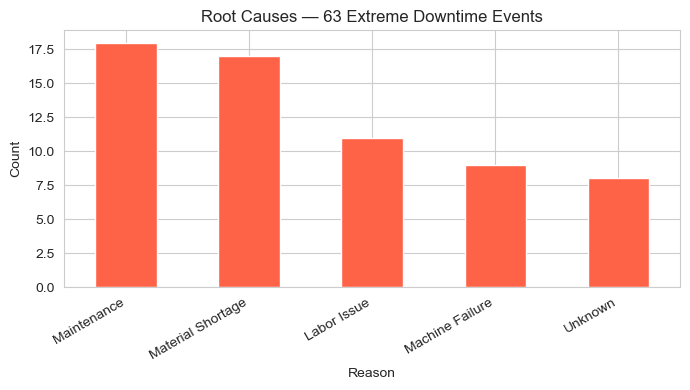

In [53]:
# Root cause of extreme downtime outliers
print('=== Downtime Outliers by Root Cause ===')
reason_counts = dt_outliers['downtime_reason'].value_counts()
print(reason_counts.to_string())

plt.figure(figsize=(7,4))
reason_counts.plot(kind='bar', color='tomato', edgecolor='white')
plt.title(f'Root Causes — {len(dt_outliers)} Extreme Downtime Events')
plt.xlabel('Reason')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

### Interpretation
- **Shipment Cost: 0 outliers** — logistics costs are consistent with no extreme spikes. The cost distribution is uniform across all shipments.
- **Production Downtime: 63 outliers (5.25%)** — 63 production runs had downtime exceeding 5.83 hours, well above the normal range.
- **Top causes:** Maintenance (18), Material Shortage (17), Labor Issue (11), Machine Failure (9).
- **Action:** Focus preventive maintenance scheduling and material buffer stock to reduce the top two causes.

---
## Summary of Findings

| Analysis | Finding | Business Action |
|---|---|---|
| Hypothesis Test | No significant link between supplier delays and downtime (p > 0.05) | Investigate internal causes — maintenance, machine failures |
| Regression | R² = 0.014 — mode/delay/quantity don't explain cost well | Collect distance & weight data; use Rail over Air for savings |
| Correlation | Lead time vs stockout: r = 0.35, p = 0.058 (borderline) | Monitor long-lead-time products; review reorder policies |
| Outlier Detection | 0 cost outliers, 63 downtime outliers (5.25%) | Prioritise Maintenance and Material Shortage reduction |